# API Client Example

This notebook demonstrates how to download one campaign with `api.client`, persist the payloads under `data/api_downloads/`, and plot the stored spectra.

**System boundary**
- Domain/boundary: `api.client` owns HTTP pagination, TLS settings, payload normalization, and CSV persistence.
- Application/orchestration: this notebook selects a campaign, triggers the download, reloads the saved CSV files, and renders figures.
- Side effects: HTTPS requests to the remote API, CSV writes under `data/`, and notebook plots.
- Pattern choice: the notebook stays thin so the boundary behavior remains testable outside Jupyter.


In [6]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


def validate_row_indices(
    n_records: int,  # Number of rows available in every loaded sensor CSV
    requested_indices: tuple[int, ...],  # Record indices requested for plotting
) -> tuple[int, ...]:  # Valid row indices in the original requested order
    """Keep only row indices that are valid for every loaded sensor CSV."""

    valid_indices = tuple(
        index for index in requested_indices if 0 <= index < n_records
    )
    if not valid_indices:
        raise ValueError("No requested row indices exist in the downloaded data")
    return valid_indices


def build_frequency_axis_mhz(
    start_freq_hz: float,  # Lower band edge from one stored measurement [Hz]
    end_freq_hz: float,  # Upper band edge from one stored measurement [Hz]
    n_bins: int,  # Number of PSD bins in the stored measurement
) -> np.ndarray:  # Frequency axis in MHz aligned with the PSD vector
    """Build an evenly spaced plotting axis for one PSD vector."""

    if n_bins <= 0:
        raise ValueError("n_bins must be positive")
    return np.linspace(start_freq_hz / 1.0e6, end_freq_hz / 1.0e6, n_bins)


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import api.client as client

client = importlib.reload(client)
pd.options.display.max_colwidth = 120


## Configure The Download

Choose one campaign label from `client.DEFAULT_CAMPAIGN_IDS` and one or more sensor labels from `client.DEFAULT_SENSOR_MAC_BY_LABEL`.


In [7]:
campaign_label = "FM original"
campaign_id = client.DEFAULT_CAMPAIGN_IDS[campaign_label]
sensor_mac_by_label = client.DEFAULT_SENSOR_MAC_BY_LABEL
output_root = REPO_ROOT / client.DEFAULT_DATA_DOWNLOAD_DIR

# The deployed API currently requires verify_tls=False in this environment.
api_client = client.MeasurementApiClient(
    client.MeasurementApiConfig(verify_tls=False, timeout_s=30.0, page_size=5000)
)

display(
    pd.DataFrame(
        [
            {
                "campaign_label": campaign_label,
                "campaign_id": campaign_id,
                "output_root": str(output_root.relative_to(REPO_ROOT)),
                "n_sensors": len(sensor_mac_by_label),
            }
        ]
    )
)
display(
    pd.DataFrame(
        [
            {"sensor_label": sensor_label, "mac": mac_address}
            for sensor_label, mac_address in sensor_mac_by_label.items()
        ]
    ).sort_values("sensor_label")
)


,campaign_label,campaign_id,output_root,n_sensors
0,FM original,176,data/api_downloads,5


,sensor_label,mac
0,Node1,d8:3a:dd:f7:1d:f2
1,Node2,d8:3a:dd:f4:4e:26
2,Node3,d8:3a:dd:f7:22:87
3,Node5,d8:3a:dd:f7:21:52
4,Node9,d8:3a:dd:f4:4e:d1


## Download And Persist CSV Files

This cell creates `data/api_downloads/<campaign>/` and writes one CSV per sensor using the same column schema as the repository's acquisition files.


In [8]:
stored_paths = api_client.download_campaign_csvs(
    campaign_label=campaign_label,
    campaign_id=campaign_id,
    sensor_mac_by_label=sensor_mac_by_label,
    output_root=output_root,
    drop_missing_pxx=True,
)

display(
    pd.DataFrame(
        [
            {
                "sensor_label": sensor_label,
                "csv_path": str(csv_path.relative_to(REPO_ROOT)),
            }
            for sensor_label, csv_path in stored_paths.items()
        ]
    ).sort_values("sensor_label")
)


,sensor_label,csv_path
0,Node1,data/api_downloads/FM_original/Node1.csv
1,Node2,data/api_downloads/FM_original/Node2.csv
2,Node3,data/api_downloads/FM_original/Node3.csv
3,Node5,data/api_downloads/FM_original/Node5.csv
4,Node9,data/api_downloads/FM_original/Node9.csv


## Reload The Saved CSV Files

The client loader parses the JSON-encoded `pxx` column into `numpy` arrays so plotting stays simple.


In [9]:
frames_by_sensor = client.load_measurement_frames(stored_paths)
summary_rows: list[dict[str, object]] = []

for sensor_label, frame in frames_by_sensor.items():
    if frame.empty:
        raise ValueError(f"Downloaded CSV for {sensor_label} is empty")

    first_row = frame.iloc[0]
    summary_rows.append(
        {
            "sensor_label": sensor_label,
            "records": len(frame),
            "frequency_start_mhz": float(first_row["start_freq_hz"]) / 1.0e6,
            "frequency_end_mhz": float(first_row["end_freq_hz"]) / 1.0e6,
            "n_bins": int(np.asarray(first_row["pxx"]).size),
            "first_timestamp_ms": int(first_row["timestamp"]),
        }
    )

summary_frame = pd.DataFrame(summary_rows).sort_values("sensor_label")
display(summary_frame)


,sensor_label,records,frequency_start_mhz,frequency_end_mhz,n_bins,first_timestamp_ms
0,Node1,105,88.0,108.0,32768,1771929017886
1,Node2,105,88.0,108.0,32768,1771929018339
2,Node3,105,88.0,108.0,32768,1771929018055
3,Node5,105,88.0,108.0,32768,1771929019374
4,Node9,105,137.0,157.0,32768,1771929002532


## Plot Stored Spectra

The figure overlays the same record index across all saved sensor CSV files. If a requested row index does not exist for every sensor, it is skipped explicitly.


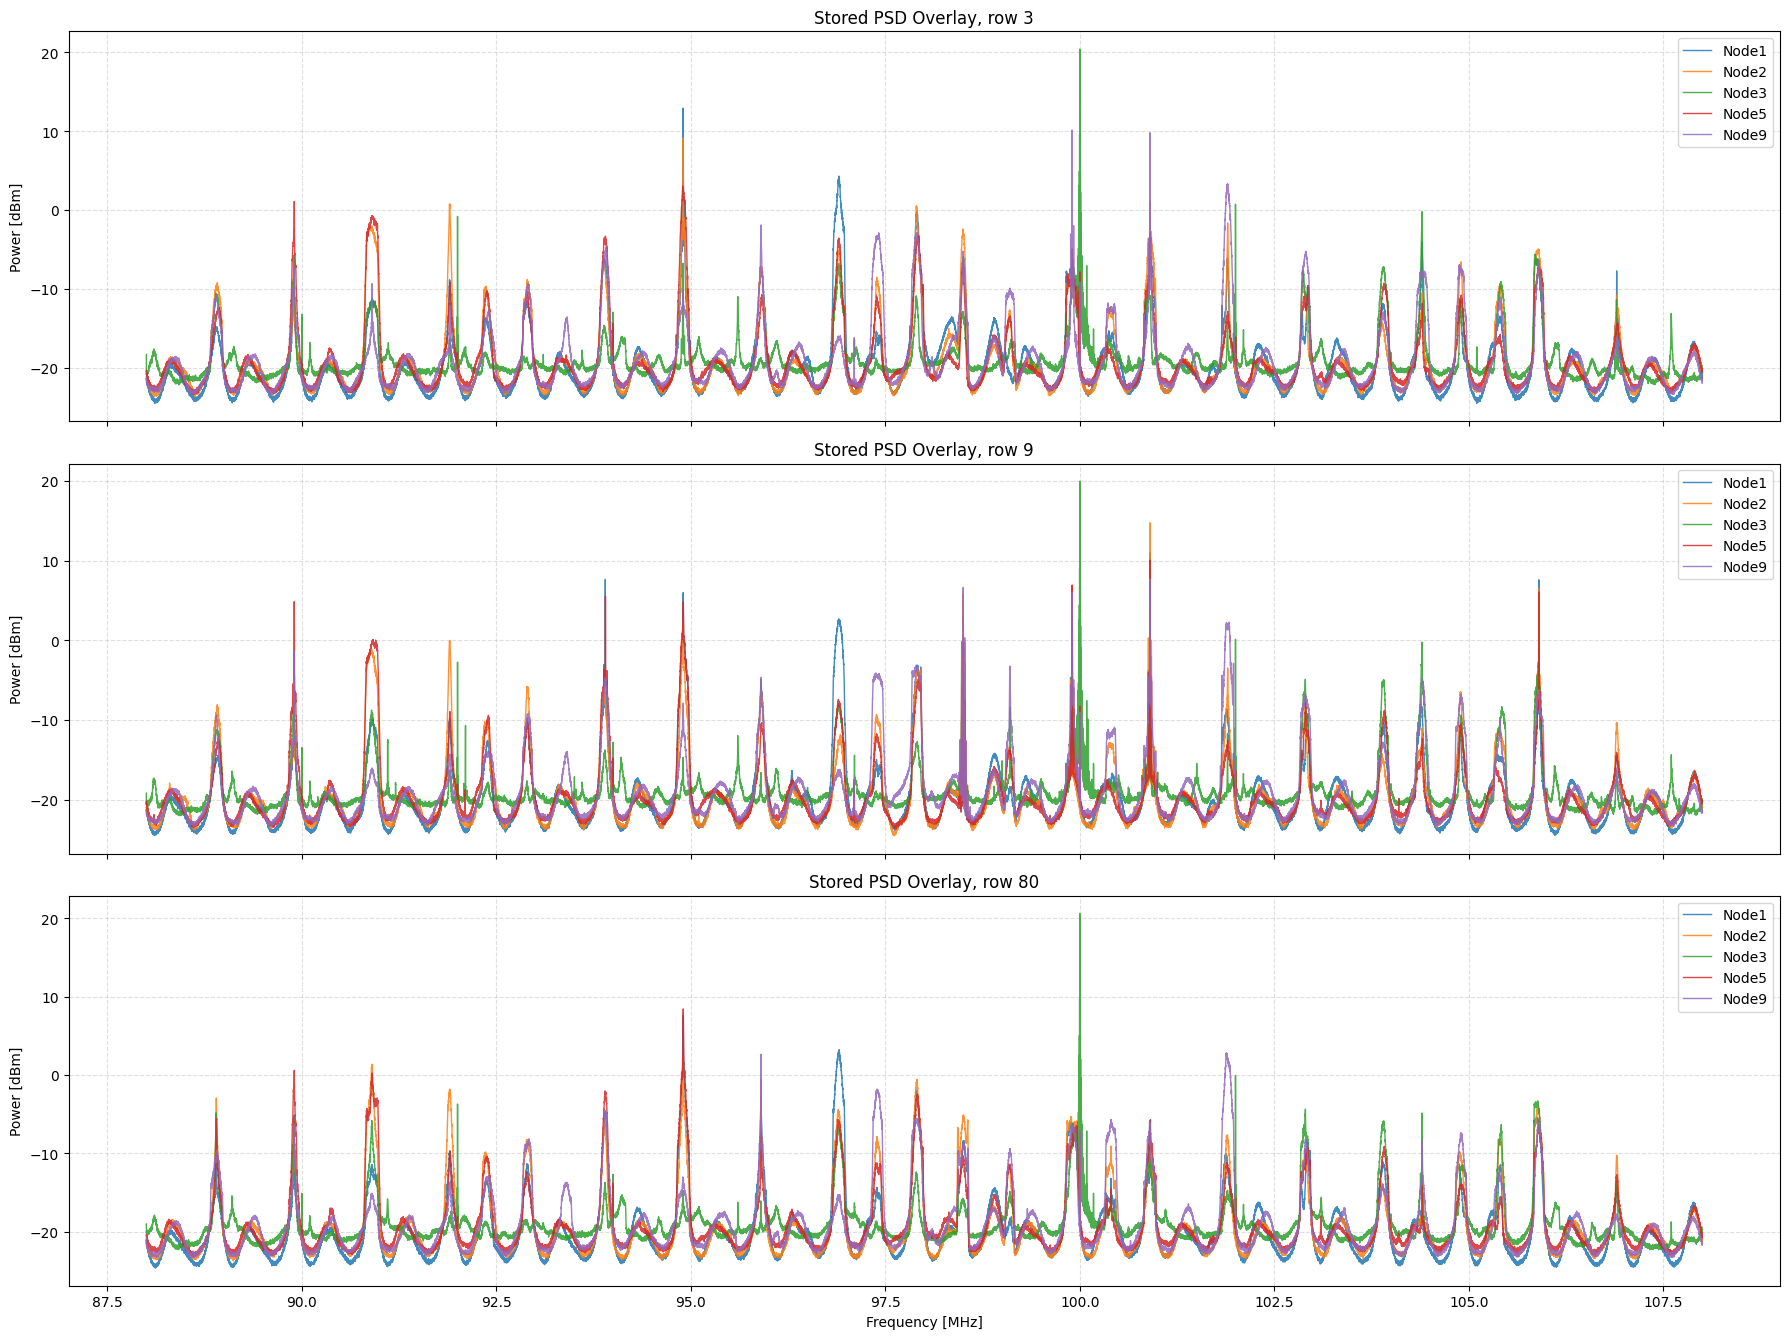

In [10]:
min_records = min(len(frame) for frame in frames_by_sensor.values())
row_indices = validate_row_indices(min_records, (3, 9, 80))

fig, axes = plt.subplots(
    nrows=len(row_indices),
    ncols=1,
    figsize=(18, 4.5 * len(row_indices)),
    sharex=True,
)
if len(row_indices) == 1:
    axes = [axes]

for ax, row_index in zip(axes, row_indices):
    for sensor_label, frame in sorted(frames_by_sensor.items()):
        row = frame.iloc[row_index]
        pxx_db = np.asarray(row["pxx"], dtype=np.float64)

        # Each stored row carries its own band edges, so build the plotting
        # axis from the persisted metadata instead of assuming a fixed band.
        frequency_mhz = build_frequency_axis_mhz(
            start_freq_hz=float(row["start_freq_hz"]),
            end_freq_hz=float(row["end_freq_hz"]),
            n_bins=pxx_db.size,
        )
        ax.plot(frequency_mhz, pxx_db, label=sensor_label, linewidth=1.0, alpha=0.85)

    ax.set_title(f"Stored PSD Overlay, row {row_index}")
    ax.set_ylabel("Power [dBm]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best")

axes[-1].set_xlabel("Frequency [MHz]")
plt.tight_layout()
plt.show()
